# Project: Stroke Risk Prediction

**Overview:** Build a classification model to predict the risk of stroke.

**Task:** Binary Classification
**Dataset:** Stroke Risk dataset


## 1. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import tensorflow as tf

## 2. Load Dataset

In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
print('Features:', df.columns)
print('Shape', df.shape)
print('Missing values: \n',df.isnull().sum())

Features: Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')
Shape (5110, 12)
Missing values: 
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


## 3. EDA

### Stroke Class Distribution

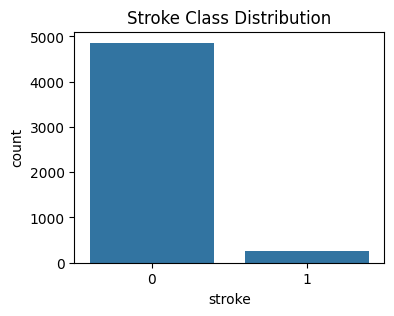

In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(data=df, x='stroke')
plt.title('Stroke Class Distribution')
plt.show()

The class distribution is heavily imbalanced (having a stroke is much rarer). This matters because a model may have high accuracy while failing to detect stroke cases.

### Correlation Heatmap

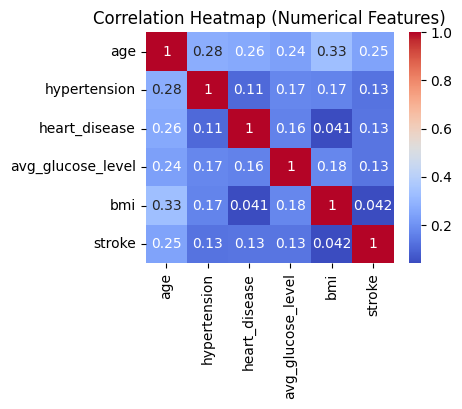

In [ ]:
# correlaation heatmap

numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
plt.figure(figsize=(4,3))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()


The heatmap shows that no single numerical feature fully predicts stroke on its own. Age and heart related features (hypertension and heart_disease) show a good signal but need to be combined to make a good prediction.

### Age Distribution by Stroke

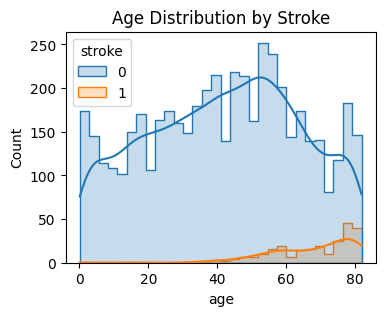

In [ ]:
# check age distribution with stroke

plt.figure(figsize=(4,3))
sns.histplot(data=df, x='age', hue='stroke', bins=30, kde=True, element='step')
plt.title('Age Distribution by Stroke')
plt.show()

Patients who have stroke are more in older ages. This reveals age-related risk pattern. Older people are high-risk groups.

### BMI Distribution by Stroke

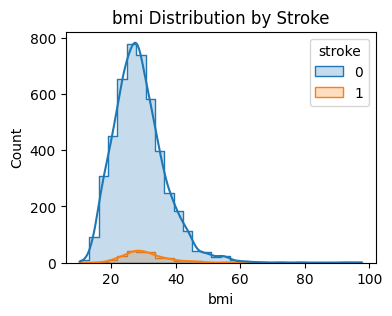

In [ ]:
plt.figure(figsize=(4,3))
sns.histplot(data=df, x='bmi', hue='stroke', bins=30, kde=True, element='step')
plt.title('bmi Distribution by Stroke')
plt.show()


BMI distributions are similar across classes. BMI alone is insufficient but will be useful when combined with other features.

### Effect of Hypertension

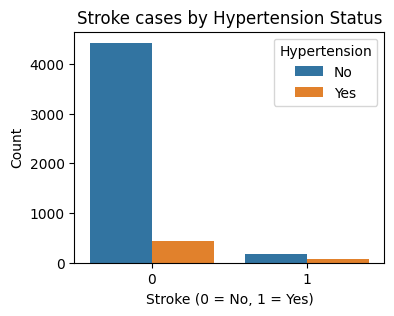

In [ ]:
#effect of hypertension

plt.figure(figsize=(4,3))
sns.countplot(data=df, x='stroke', hue='hypertension')
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Stroke cases by Hypertension Status")
plt.legend(title='Hypertension', labels=['No', 'Yes'])
plt.show()

Eventhough the count of patients who have stroke is low, the ratio of number of with hypertension who have stroke is higher. This means patients who have hypertension are more likely to have stroke.

### Effect of Heart Disease

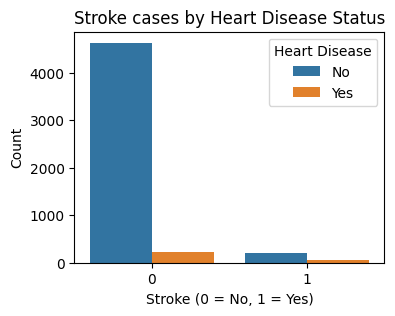

In [ ]:
#effect of heart disease


plt.figure(figsize=(4,3))
sns.countplot(data=df, x='stroke', hue='heart_disease')
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Stroke cases by Heart Disease Status")
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.show()

Heart Disease is associated with a higher proportion pf stroke cases. This also indicates that patients with heart disease are more likely to have a stroke.

### Glucose Level vs Stroke

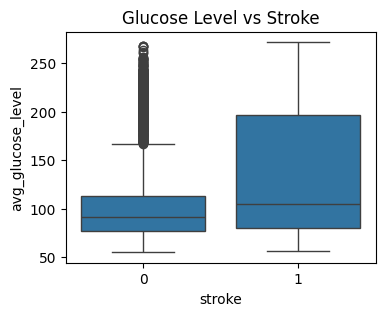

In [ ]:
# glucose level

plt.figure(figsize=(4,3))
sns.boxplot(data=df, x='stroke', y='avg_glucose_level')
plt.title('Glucose Level vs Stroke')
plt.show()

Stroke cases shows higher glucose levels and wider spread. However Non-stroke cases have more outliers and must be handled.

## Insights and Assumptions

1. Stroke cases are rare (class imbalance), so recall and F1 are more informative than accuracy.

2. Age and cardiovascular conditions are correlated with stroke status but interact with other lifestyle features to give a strong prediction.

## 4. Preprocessing

In [ ]:
df = df.drop(columns = ['id'])
df['bmi'] = df['bmi'].fillna(df['bmi'].median())


X = df.drop(columns=['stroke'])
y = df['stroke']

# divide into train, validation and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# make a list of categorical features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
# make a list of numerical features
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers = [
        ('num', Pipeline([
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', Pipeline([
            ('onehot', OneHotEncoder())
        ]), categorical_features)
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)
X_test_preprocessed = preprocessor.transform(X_test)

ID column is dropped because its not predictive.

Missing BMI values is filled with median to keep valuble medical data.

Scaling and encoding are applied to make numerical/categorical features model ready.

When splitting the dataset, stratify is used to preserve class proportions since we have low number of stroke cases.

In [ ]:
print(
    X_train_preprocessed.shape,
    X_val_preprocessed.shape,
    X_test_preprocessed.shape,
    )

(3270, 21) (818, 21) (1022, 21)


## 5. Model Building

### 5.1 Baseline Model

This baseline model is intentionally simple so we can measure the gains from later improvements. It will a reference point to check later changes will create meaningful benifit.

In [ ]:
def build_model(input_dim):
  model = Sequential()
  model.add(Dense(32, activation='relu', input_dim=input_dim))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

input_dim = X_train_preprocessed.shape[1]

model_baseline = build_model(input_dim)

# train
history_baseline = model_baseline.fit(
    X_train_preprocessed, y_train,
    validation_data=(X_val_preprocessed, y_val),
    epochs=30,
    batch_size=32,
)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7410 - loss: 0.5458 - val_accuracy: 0.9511 - val_loss: 0.2142
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9560 - loss: 0.1899 - val_accuracy: 0.9511 - val_loss: 0.1773
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9489 - loss: 0.1752 - val_accuracy: 0.9511 - val_loss: 0.1680
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9496 - loss: 0.1668 - val_accuracy: 0.9511 - val_loss: 0.1637
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9475 - loss: 0.1702 - val_accuracy: 0.9511 - val_loss: 0.1612
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9450 - loss: 0.1720 - val_accuracy: 0.9511 - val_loss: 0.1599
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9549 - loss: 0.1502 - val_accuracy: 0.9511 - val_loss: 0.1593
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9491 - loss: 0.1555 - val_accuracy: 0.9511 - val_

We will make an evaluation function so that comparison will be easier in later improvements using accuracy, precision, recall, F1 and confusion matrix. We will focus on recall/F1 for the stroke class (stroke = 1). Recall/F1 is important for decision making becaused any missed stroke cases are costly.

In [ ]:
# evaluate

def evaluate_model(model, X_test, y_test, threshold=0.5, name='Model'):
  probabilities = model.predict(X_test)
  predictions = (probabilities >= threshold).astype(int) # change probabilty to class

  acc = accuracy_score(y_test, predictions)
  prec = precision_score(y_test, predictions)
  rec = recall_score(y_test, predictions)
  f1 = f1_score(y_test, predictions)
  cm = confusion_matrix(y_test, predictions)

  return {'name': name,
          'accuracy': acc,
          'precision': prec,
          'recall': rec,
          'f1': f1,
          'cm': cm,
          }

baseline_metrics = evaluate_model(model_baseline, X_test_preprocessed, y_test, 0.5, 'Baseline Model')
baseline_metrics

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


{'name': 'Baseline Model',
 'accuracy': 0.952054794520548,
 'precision': 1.0,
 'recall': 0.02,
 'f1': 0.0392156862745098,
 'cm': array([[972,   0],
        [ 49,   1]])}

The accuracy is 95.2%. Its high but misleading. The dataset is imbalanced thats why the accuracy look great.

The precision is 100%. The model predicted  1 positive stroke case and got it correct.

The recall is 2%. The model misses almost all of stroke cases. This is a disastor for a medical model.

F1 is 3% and greatly affected by low recall.

Looking at the confusion matrix the model correctly identifies healthy patients (TN = 972), and never flagged a healthy patient incorrectly (FN = 0). However almost all stroke patients missed (FP = 49).

## 6. Model Improvement

Our baseline model is unsafe because it misses all stroke patients. It can't be used for screening or early detection.

The reason for that is the model is biased toward the majority class (healthy).

To address this issue, we will optimize for recall and accept lower precision if needed. We need to handle the imbalance in the dataset and adjust the decision threshold as well.

### 6.1 Class Weights

compute_class_weights is a function in scikit-learn that is used to counter imbalance by giving more importance to the minority class during training. The function returns a list of weights that will be used in our model to penalize mistakes on stroke cases more heavily.

In [ ]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
# store as dictionary
class_weight_dict = {0: weights[0], 1: weights[1]}

print('Class weights:', class_weight_dict) # The stroke error is penalized 20x more than non-stroke

Class weights: {0: np.float64(0.5255544840887174), 1: np.float64(10.283018867924529)}


We will train our baseline model with the new class weights:

In [ ]:
weights_balanced_model = build_model(input_dim)
history_weights_balanced = weights_balanced_model.fit(
    X_train_preprocessed, y_train,
    validation_data=(X_val_preprocessed, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4158 - loss: 0.7327 - val_accuracy: 0.6235 - val_loss: 0.6298
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6537 - loss: 0.5804 - val_accuracy: 0.7298 - val_loss: 0.5128
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7214 - loss: 0.5361 - val_accuracy: 0.7090 - val_loss: 0.5435
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6909 - loss: 0.5205 - val_accuracy: 0.7262 - val_loss: 0.5104
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7160 - loss: 0.5046 - val_accuracy: 0.7237 - val_loss: 0.5177
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7311 - loss: 0.4660 - val_accuracy: 0.7262 - val_loss: 0.5117
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7112 - loss: 0.4740 - val_accuracy: 0.7176 - val_loss: 0.5388
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7251 - loss: 0.4644 - val_accuracy: 0.7249 - val_

In [ ]:
weights_balanced_metrics = evaluate_model(weights_balanced_model, X_test_preprocessed, y_test, 0.5, name='Weights Balanced Model')
weights_balanced_metrics

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


{'name': 'Weights Balanced Model',
 'accuracy': 0.7700587084148728,
 'precision': 0.14559386973180077,
 'recall': 0.76,
 'f1': 0.24437299035369775,
 'cm': array([[749, 223],
        [ 12,  38]])}

Recall improved significantly to 76.0%. This is a major success. Our model is now safer.

Precision dropped to 14.6%. Our model now have less precision and gives too many false alarms meaning it needs further investigation if predicted stroke.

f1 score increased to 24.4%. Good improvement but still low due to lower precision.

Accuracy is now 77.0% but no longer misleading.

Looking at the confusion matrix, TP increased from 0 to 38 (huge improvement).

### 6.2 Deeper Architecture

Our next strategy is deeper architecture to add more capacity to learn non-linear interactions. Early stopping will control ovefitting. This is justified because stroke risk likely depends on many factors interacting together rather than linear effects only.

We will perform grid search for our model to optimize on recall score for the stroke class. We choose a hyperparameter grid including number of neurons, learning rate and batch size.

In [ ]:
def build_tunable_model(input_dim, units_1=64, units_2=32, learning_rate=0.003):
  model = Sequential()
  model.add(Dense(units_1, activation='relu', input_dim=input_dim))
  model.add(Dense(units_2, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

#Grid
param_grid = {
    'units_1': [64, 128],
    'units_2': [32, 64],
    'learning_rate': [0.001, 0.0005, 0.0001],
    'batch_size': [32, 64],
    'epochs': [50]
}

best_model = None
best_params = None
best_val_recall = -1

for params in ParameterGrid(param_grid):

  model = build_tunable_model(
      input_dim=input_dim,
      units_1=params['units_1'],
      units_2=params['units_2'],
      learning_rate=params['learning_rate']
  )

  early_stop = tf.keras.callbacks.EarlyStopping(
      monitor='val_loss',
      patience=5,
      restore_best_weights=True
  )

  model.fit(
      X_train_preprocessed,
      y_train,
      validation_data=(X_val_preprocessed, y_val),
      epochs=params['epochs'],
      batch_size=params['batch_size'],
      class_weight=class_weight_dict,
      callbacks=[early_stop],
  )

  val_probs = model.predict(X_val_preprocessed)
  val_preds = (val_probs >= 0.5).astype(int)
  val_recall = recall_score(y_val, val_preds)

  if val_recall > best_val_recall:
    best_val_recall = val_recall
    best_params = params
    best_model = model

print('Best NN params:', best_params)
print('Best validation recall', best_val_recall)




Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8572 - loss: 0.6118 - val_accuracy: 0.6858 - val_loss: 0.5436
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6643 - loss: 0.5218 - val_accuracy: 0.6968 - val_loss: 0.5243
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6673 - loss: 0.4782 - val_accuracy: 0.7005 - val_loss: 0.5254
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6968 - loss: 0.4591 - val_accuracy: 0.7029 - val_loss: 0.5304
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7018 - loss: 0.4356 - val_accuracy: 0.7262 - val_loss: 0.4957
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7187 - loss: 0.4402 - val_accuracy: 0.7408 - val_loss: 0.4274
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7525 - loss: 0.4411 - val_accuracy: 0.7225 - val_loss: 0.4949
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7210 - loss: 0.4809 - val_accuracy: 0.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7895 - loss: 0.6018 - val_accuracy: 0.7726 - val_loss: 0.4571
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7460 - loss: 0.4664 - val_accuracy: 0.7042 - val_loss: 0.5318
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7273 - loss: 0.4530 - val_accuracy: 0.6736 - val_loss: 0.5936
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7157 - loss: 0.4289 - val_accuracy: 0.7078 - val_loss: 0.5253
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7221 - loss: 0.4220 - val_accuracy: 0.7237 - val_loss: 0.4797
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7057 - loss: 0.4691 - val_accuracy: 0.7469 - val_loss: 0.4650
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5916 - loss: 0.6179 - val_accuracy: 0.6699 - val_loss: 0.5756
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6822 - loss: 0.4946 - val_accuracy: 0.7286 - val_loss: 0.4822
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7075 - loss: 0.4675 - val_accuracy: 0.7066 - val_loss: 0.5196
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7199 - loss: 0.4613 - val_accuracy: 0.7323 - val_loss: 0.4473
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7104 - loss: 0.4574 - val_accuracy: 0.7359 - val_loss: 0.4657
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7469 - loss: 0.4096 - val_accuracy: 0.7323 - val_loss: 0.4612
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7473 - loss: 0.4129 - val_accuracy: 0.7103 - val_loss: 0.5273
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6667 - loss: 0.4594 - val_accuracy: 0.7078 - val_

...

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7335 - loss: 0.7353 - val_accuracy: 0.7237 - val_loss: 0.6416
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7537 - loss: 0.7119 - val_accuracy: 0.7494 - val_loss: 0.6304
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7487 - loss: 0.6431 - val_accuracy: 0.6993 - val_loss: 0.6229
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7051 - loss: 0.6284 - val_accuracy: 0.6932 - val_loss: 0.6056
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7031 - loss: 0.5522 - val_accuracy: 0.6932 - val_loss: 0.5956
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6854 - loss: 0.6050 - val_accuracy: 0.7017 - val_loss: 0.5760
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6820 - loss: 0.5864 - val_accuracy: 0.6980 - val_loss: 0.5613
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7054 - loss: 0.5480 - val_accuracy: 0.7042 - val_loss: 0.5441
Epo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3752 - loss: 0.6931 - val_accuracy: 0.5721 - val_loss: 0.6881
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6383 - loss: 0.6613 - val_accuracy: 0.6748 - val_loss: 0.6596
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6969 - loss: 0.6114 - val_accuracy: 0.6773 - val_loss: 0.6381
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7086 - loss: 0.6089 - val_accuracy: 0.6956 - val_loss: 0.6122
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7210 - loss: 0.6377 - val_accuracy: 0.7054 - val_loss: 0.5896
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7172 - loss: 0.5676 - val_accuracy: 0.7164 - val_loss: 0.5692
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7428 - loss: 0.5281 - val_accuracy: 0.7164 - val_loss: 0.5550
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7143 - loss: 0.5595 - val_accuracy: 0.7042 - val_loss: 0.5498
Epo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4946 - loss: 0.7248 - val_accuracy: 0.6736 - val_loss: 0.6791
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6904 - loss: 0.6323 - val_accuracy: 0.7176 - val_loss: 0.6565
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7118 - loss: 0.6577 - val_accuracy: 0.7127 - val_loss: 0.6280
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7139 - loss: 0.6092 - val_accuracy: 0.7188 - val_loss: 0.5986
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7079 - loss: 0.5899 - val_accuracy: 0.7152 - val_loss: 0.5757
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7282 - loss: 0.5410 - val_accuracy: 0.7115 - val_loss: 0.5550
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7227 - loss: 0.5383 - val_accuracy: 0.7298 - val_loss: 0.5310
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7194 - loss: 0.5541 - val_accuracy: 0.7176 - val_loss: 0.5211
Epo

After the Grid Search we found that the best parameters are for our deeper model are:
* Batch Size = 32
* Learning Rate = 0.0001
* Neurons in first layer = 64
* Neurons in Second layer = 32
* Epochs = 50

In [ ]:
def build_deeper_model(input_dim):
  model = Sequential()
  model.add(Dense(64, activation='relu', input_dim=input_dim))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

deeper_model = build_deeper_model(input_dim)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_deeper = deeper_model.fit(
    X_train_preprocessed, y_train,
    validation_data=(X_val_preprocessed, y_val),
    epochs=50,
    batch_size=32,
    class_weight = class_weight_dict,
    callbacks = [early_stop],
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4719 - loss: 0.6608 - val_accuracy: 0.5892 - val_loss: 0.6839
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6197 - loss: 0.6097 - val_accuracy: 0.6455 - val_loss: 0.6394
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6593 - loss: 0.6111 - val_accuracy: 0.6797 - val_loss: 0.6002
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7033 - loss: 0.5284 - val_accuracy: 0.6858 - val_loss: 0.5808
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6950 - loss: 0.5277 - val_accuracy: 0.6932 - val_loss: 0.5663
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6966 - loss: 0.5008 - val_accuracy: 0.6980 - val_loss: 0.5541
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7076 - loss: 0.4847 - val_accuracy: 0.6968 - val_loss: 0.5552
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7000 - loss: 0.5137 - val_accuracy: 0.7005 - val_

In [ ]:
deeper_model_metrics = evaluate_model(deeper_model, X_test_preprocessed, y_test, 0.5, 'Deeper Model + Weights Balanced')
deeper_model_metrics

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


{'name': 'Deeper Model + Weights Balanced',
 'accuracy': 0.7250489236790607,
 'precision': 0.12861736334405144,
 'recall': 0.8,
 'f1': 0.22160664819944598,
 'cm': array([[701, 271],
        [ 10,  40]])}

Recall increased to 80%. This is good for a first serious medical model.

Precision decreased to 12.9%. There are still many false alarms.

F1 increased to 22.2%. It is low because because of low precision and is expected in an imbalanced dataset.

Accuracy also decreased to 72.5%. The model is no longer cheating by predicting only nonstroke class 0.

### 6.3 Decision Threshold Tuning

Our next strategy is tuning the decision threshold. The decision threshold (0.5 in our case) is arbitrary and may not be optimal for our data. We will optimize the threshold for maximum Recall score while also not sacrificing precision too much.

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


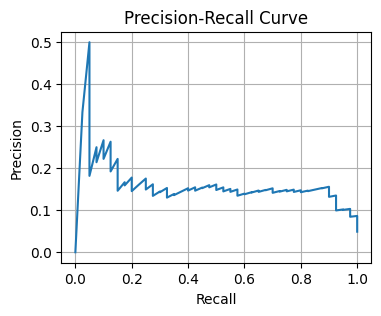

Best threshold on validation (Recall-score): 0.5500372052192688
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


{'name': 'Decision Threshold Tuned',
 'accuracy': 0.7524461839530333,
 'precision': 0.1413427561837456,
 'recall': 0.8,
 'f1': 0.24024024024024024,
 'cm': array([[729, 243],
        [ 10,  40]])}

In [ ]:
from sklearn.metrics import precision_recall_curve
val_probs = deeper_model.predict(X_val_preprocessed)

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)

plt.figure(figsize=(4,3))
plt.plot(recall[:-1], precision[:-1])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

# thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0.5
best_recall = -1.0

for i in range(len(thresholds)):
  val_preds = (val_probs >= thresholds[i]).astype(int)
  score = recall[i]

  if (score > best_recall and (precision[i] >= 0.155)):
    best_recall = score
    best_threshold = thresholds[i]

print(f'Best threshold on validation (Recall-score): {best_threshold}')


dt_tuned_metrics = evaluate_model(deeper_model, X_test_preprocessed, y_test, threshold=best_threshold, name='Decision Threshold Tuned')
dt_tuned_metrics

We managed to increase precision to 14.1%, while Recall is preserved at 80%. This is best case scenario for threshold tuning.

## 7. Compare Model Performance

In [ ]:
results = pd.DataFrame([baseline_metrics, weights_balanced_metrics, deeper_model_metrics, dt_tuned_metrics])[['name','accuracy','precision', 'recall', 'f1']]
display(results.sort_values(by='recall'))

,name,accuracy,precision,recall,f1
0,Baseline Model,0.952055,1.000000,0.02,0.039216
1,Weights Balanced Model,0.770059,0.145594,0.76,0.244373
2,Deeper + Weights Balanced,0.725049,0.128617,0.80,0.221607
3,Decision Threshold Tuned,0.752446,0.141343,0.80,0.240240


1. Baseline Model

Accuracy looks excellent but is misleading. This model misses 98% of stroke cases. This model is statistically good but useless in real life especially in our case.

2. Weights Balanced Model

After addressing the classes imbalance issue, Recall jumped to 76%. This makes it a solid screening model, we can now flag stroke patients with more confidence. However, the precision dropped to 14.6% but its still within acceptable range.

3. Deeper Architecture Model

Using grid search we found the best parameters for our deeper model to increase recall and managed to achieve 80% however precision dropped further to 12.9%.

4. Decision Threshold Tuned

We managed to recover precision while maintaining the recall score.

## 8. Final Answer and Recommendations for Healthcare Teams

Final model choice: Decision Threshold Tuned. This model provides the most reliable recall and F1 on test data with acceptable precision.

This model is safe and reliable to use but only as clinical decision support screening tool. It should not be used as diagnostic system.

Class weighting and threshold tuning improved minority class detection. The key impact it that we can better capture stroke patients.

* I recommed healthcare teams to use the model as support tool to detect stroke signals early and then do further investigations.

* Additionally, keep monitoring recall, precision and F1 over time.

* Retrain regularly with updated, newer data.

* Pair the model predictions with healthcare professional review.
